In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('data.csv')
print(df.head())

  project_id  year           domain   model_type  dataset_size  \
0      PRJ_1  2025          finance      XGBoost         41590   
1      PRJ_2  2020  computer_vision          CNN         69592   
2      PRJ_3  2023          finance          CNN         10192   
3      PRJ_4  2024          finance     DenseNet          3068   
4      PRJ_5  2018          medical  Transformer         98518   

   class_imbalance_ratio  label_noise_level  missing_data_ratio  data_leakage  \
0               0.353677           0.046806            0.038999             0   
1               0.110945           0.136821            0.196294             0   
2               0.376237           0.077634            0.165631             1   
3               0.107264           0.084280            0.135674             0   
4               0.230751           0.093295            0.081296             0   

   overfitting_score  ...  precision    recall  f1_score   roc_auc  \
0           0.969910  ...   0.591702  0.652121

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 24 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   project_id              6000 non-null   object 
 1   year                    6000 non-null   int64  
 2   domain                  6000 non-null   object 
 3   model_type              6000 non-null   object 
 4   dataset_size            6000 non-null   int64  
 5   class_imbalance_ratio   6000 non-null   float64
 6   label_noise_level       6000 non-null   float64
 7   missing_data_ratio      6000 non-null   float64
 8   data_leakage            6000 non-null   int64  
 9   overfitting_score       6000 non-null   float64
 10  train_val_gap           6000 non-null   float64
 11  unstable_training       6000 non-null   int64  
 12  underfitting_flag       6000 non-null   int64  
 13  accuracy                6000 non-null   float64
 14  precision               6000 non-null   

In [4]:
df.describe()

,year,dataset_size,class_imbalance_ratio,label_noise_level,missing_data_ratio,data_leakage,overfitting_score,train_val_gap,unstable_training,underfitting_flag,accuracy,precision,recall,f1_score,roc_auc,architecture_change,threshold_optimization,post_fix_f1_score
count,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000
mean,2021.941167,60257.107500,0.287801,0.148050,0.125281,0.101333,0.498994,0.199352,0.155667,0.100667,0.701351,0.750529,0.750832,0.576338,0.775770,0.302667,0.391167,0.726351
std,2.613652,34720.642123,0.157935,0.086423,0.072198,0.301795,0.290112,0.114755,0.362569,0.300912,0.114746,0.145572,0.143584,0.122612,0.101142,0.459450,0.488052,0.134802
min,2018.000000,536.000000,0.050000,0.000073,0.000035,0.000000,0.000398,0.000002,0.000000,0.000000,0.500039,0.500094,0.500005,0.302325,0.600053,0.000000,0.000000,0.375529
25%,2020.000000,29877.750000,0.164268,0.073871,0.063351,0.000000,0.243648,0.099824,0.000000,0.000000,0.602732,0.624154,0.627788,0.476815,0.687525,0.000000,0.000000,0.624540
50%,2022.000000,60051.000000,0.268209,0.147783,0.126278,0.000000,0.500892,0.199369,0.000000,0.000000,0.703242,0.748804,0.750823,0.577689,0.776782,0.000000,0.000000,0.726823
75%,2024.000000,90510.250000,0.390597,0.222836,0.187465,0.000000,0.752372,0.299213,0.000000,0.000000,0.798851,0.878726,0.876081,0.675215,0.862495,1.000000,1.000000,0.830140
max,2026.000000,119972.000000,0.888717,0.299913,0.249989,1.000000,0.999891,0.399930,1.000000,1.000000,0.899901,0.999899,0.999931,0.846198,0.949997,1.000000,1.000000,1.000000


In [5]:
df.shape

(6000, 24)

In [6]:
df.isnull().sum()

project_id                0
year                      0
domain                    0
model_type                0
dataset_size              0
class_imbalance_ratio     0
label_noise_level         0
missing_data_ratio        0
data_leakage              0
overfitting_score         0
train_val_gap             0
unstable_training         0
underfitting_flag         0
accuracy                  0
precision                 0
recall                    0
f1_score                  0
roc_auc                   0
failure_type              0
applied_augmentation      0
rebalancing_method        0
architecture_change       0
threshold_optimization    0
post_fix_f1_score         0
dtype: int64

In [7]:
df.duplicated().sum()

0

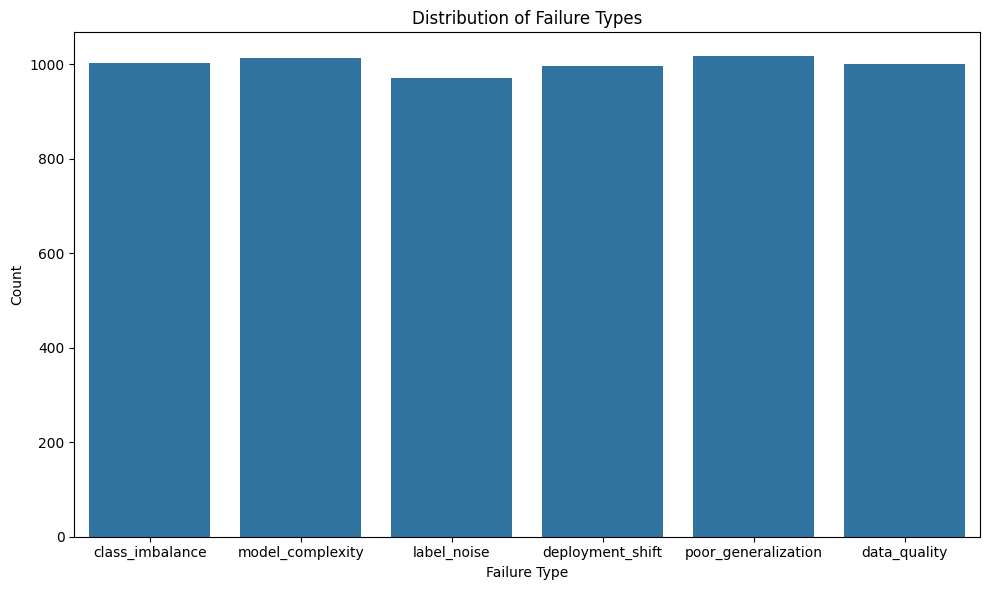

In [8]:
plt.figure(figsize=(10,6))
sns.countplot(x='failure_type', data = df)
plt.title('Distribution of Failure Types')
plt.xlabel('Failure Type')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('failure_type_distribution.png')
plt.show()

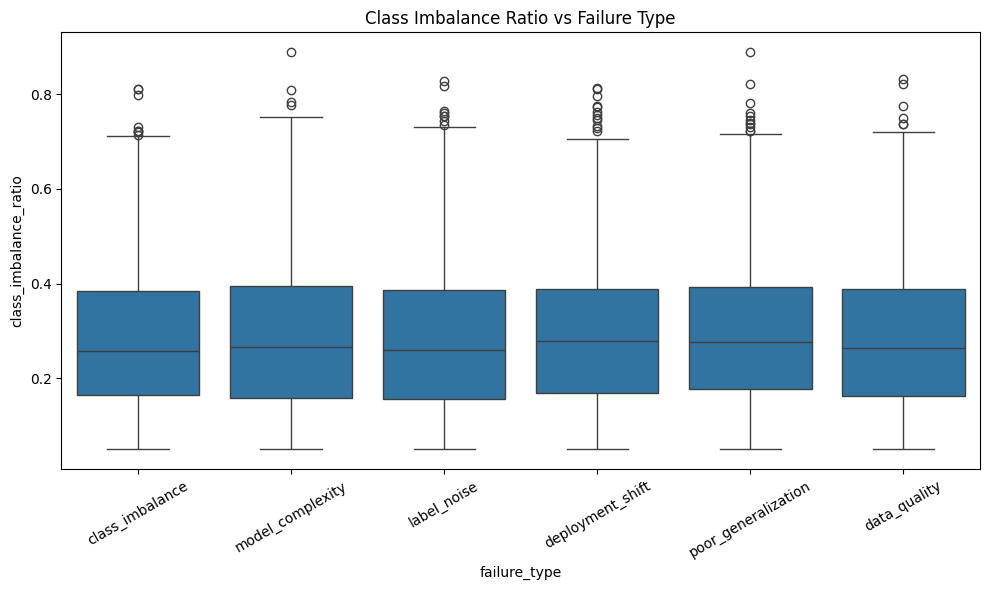

In [11]:
plt.figure(figsize = (10,6))
sns.boxplot(data=df, x="failure_type", y="class_imbalance_ratio")
plt.title("Class Imbalance Ratio vs Failure Type")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('class_imbalance_ratio_vs_failure_type.png')
plt.show()

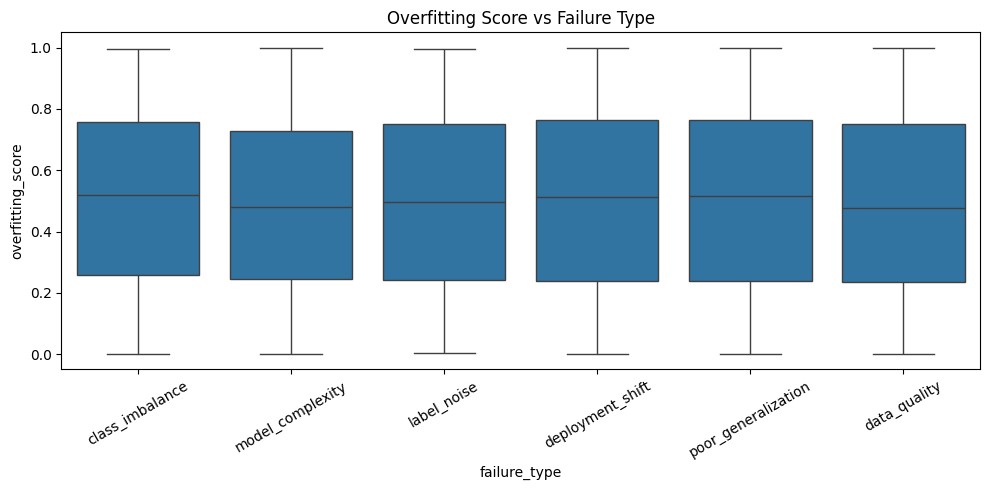

In [12]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x="failure_type", y="overfitting_score")
plt.title("Overfitting Score vs Failure Type")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('overfitting_score_vs_failure_type.png')
plt.show()

In [17]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [19]:
X = df.drop(columns = ["project_id" , "failure_type"])
y = df["failure_type"]
for col in X.select_dtypes(include=['object']).columns:
    X[col] = LabelEncoder().fit_transform(X[col])
y = LabelEncoder().fit_transform(y)
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42 , max_depth=14, min_samples_split=5, n_jobs=1)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("\nCLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred))



CLASSIFICATION REPORT:
              precision    recall  f1-score   support

           0       0.17      0.19      0.18       201
           1       0.17      0.18      0.17       193
           2       0.13      0.15      0.14       185
           3       0.16      0.13      0.15       201
           4       0.14      0.12      0.13       208
           5       0.18      0.18      0.18       212

    accuracy                           0.16      1200
   macro avg       0.16      0.16      0.16      1200
weighted avg       0.16      0.16      0.16      1200



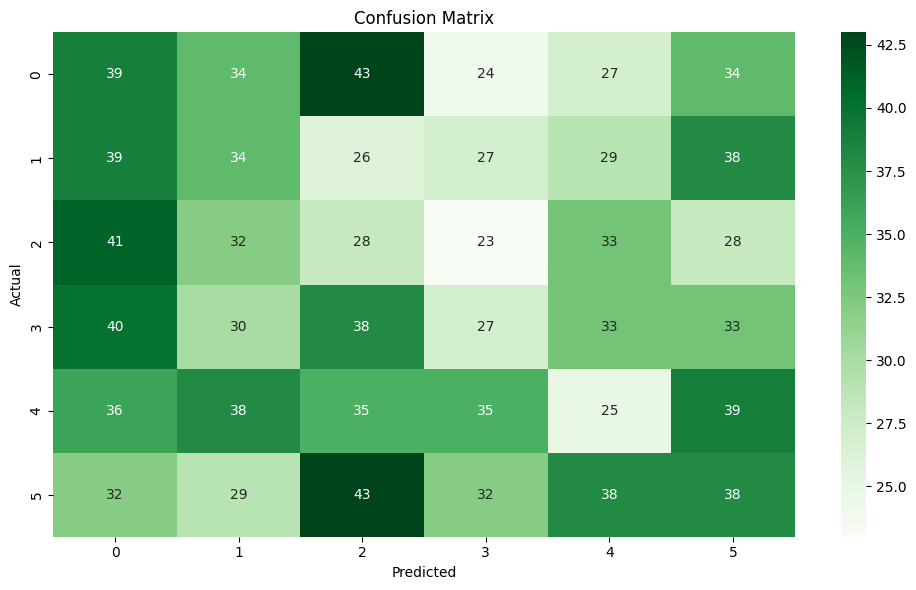

In [22]:
plt.figure(figsize = (10,6))
sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt='d',
    cmap="Greens"
)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()

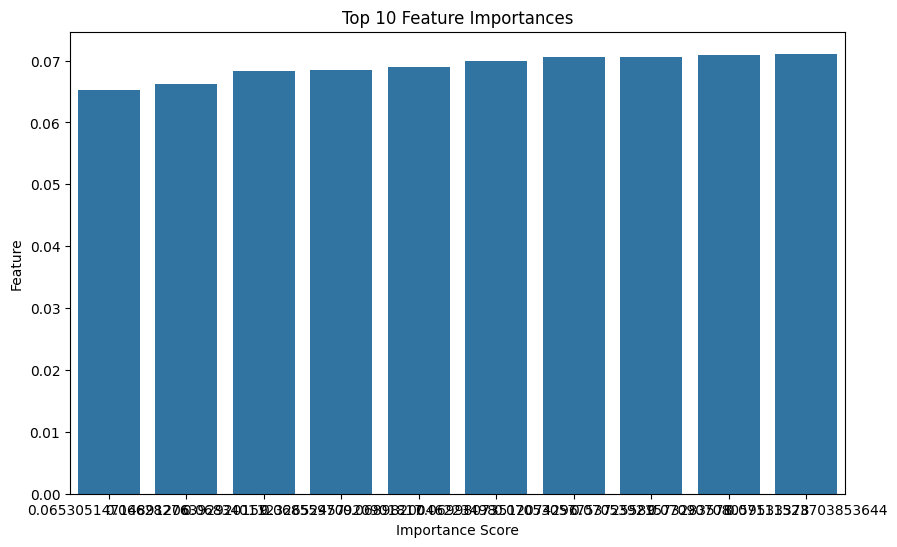

In [24]:
importances = (
    pd.Series(model.feature_importances_, index = X.columns)
    .sort_values(ascending=False)
)

plt.figure(figsize = (10, 6))
sns.barplot(x=importances[:10], y=importances[:10])
plt.title('Top 10 Feature Importances')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.savefig('feature_importances.png')
plt.show()

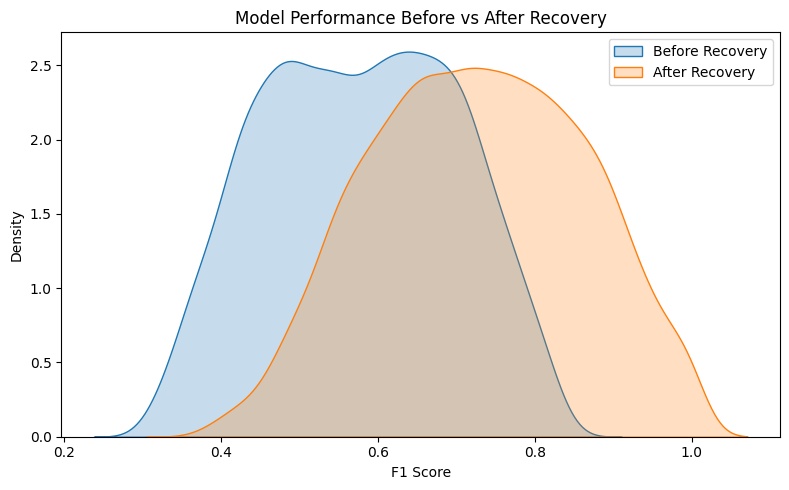

In [25]:
plt.figure(figsize=(8,5))
sns.kdeplot(df["f1_score"], label="Before Recovery", fill=True)
sns.kdeplot(df["post_fix_f1_score"], label="After Recovery", fill=True)
plt.title("Model Performance Before vs After Recovery")
plt.xlabel("F1 Score")
plt.legend()
plt.tight_layout()
plt.savefig('f1_score_comparison.png')
plt.show()

In [26]:
df_clean = df.copy()


EXPLORATORY DATA ANALYSIS

Failure Type Distribution ('failure_type'):
failure_type
poor_generalization    1017
model_complexity       1013
class_imbalance        1003
data_quality           1000
deployment_shift        996
label_noise             971
Name: count, dtype: int64

   Percentages:
failure_type
poor_generalization    16.950000
model_complexity       16.883333
class_imbalance        16.716667
data_quality           16.666667
deployment_shift       16.600000
label_noise            16.183333
Name: count, dtype: float64

🌍 Domain Distribution ('domain'):
domain
fraud              1040
finance            1003
computer_vision     999
nlp                 988
recommender         986
medical             984
Name: count, dtype: int64

🤖 Model Type Distribution ('model_type'):
model_type
CNN             1025
DenseNet        1023
XGBoost         1017
Transformer     1017
EfficientNet     963
Hybrid           955
Name: count, dtype: int64

 f1_score Distribution:
   Mean: 0.5763
   Med

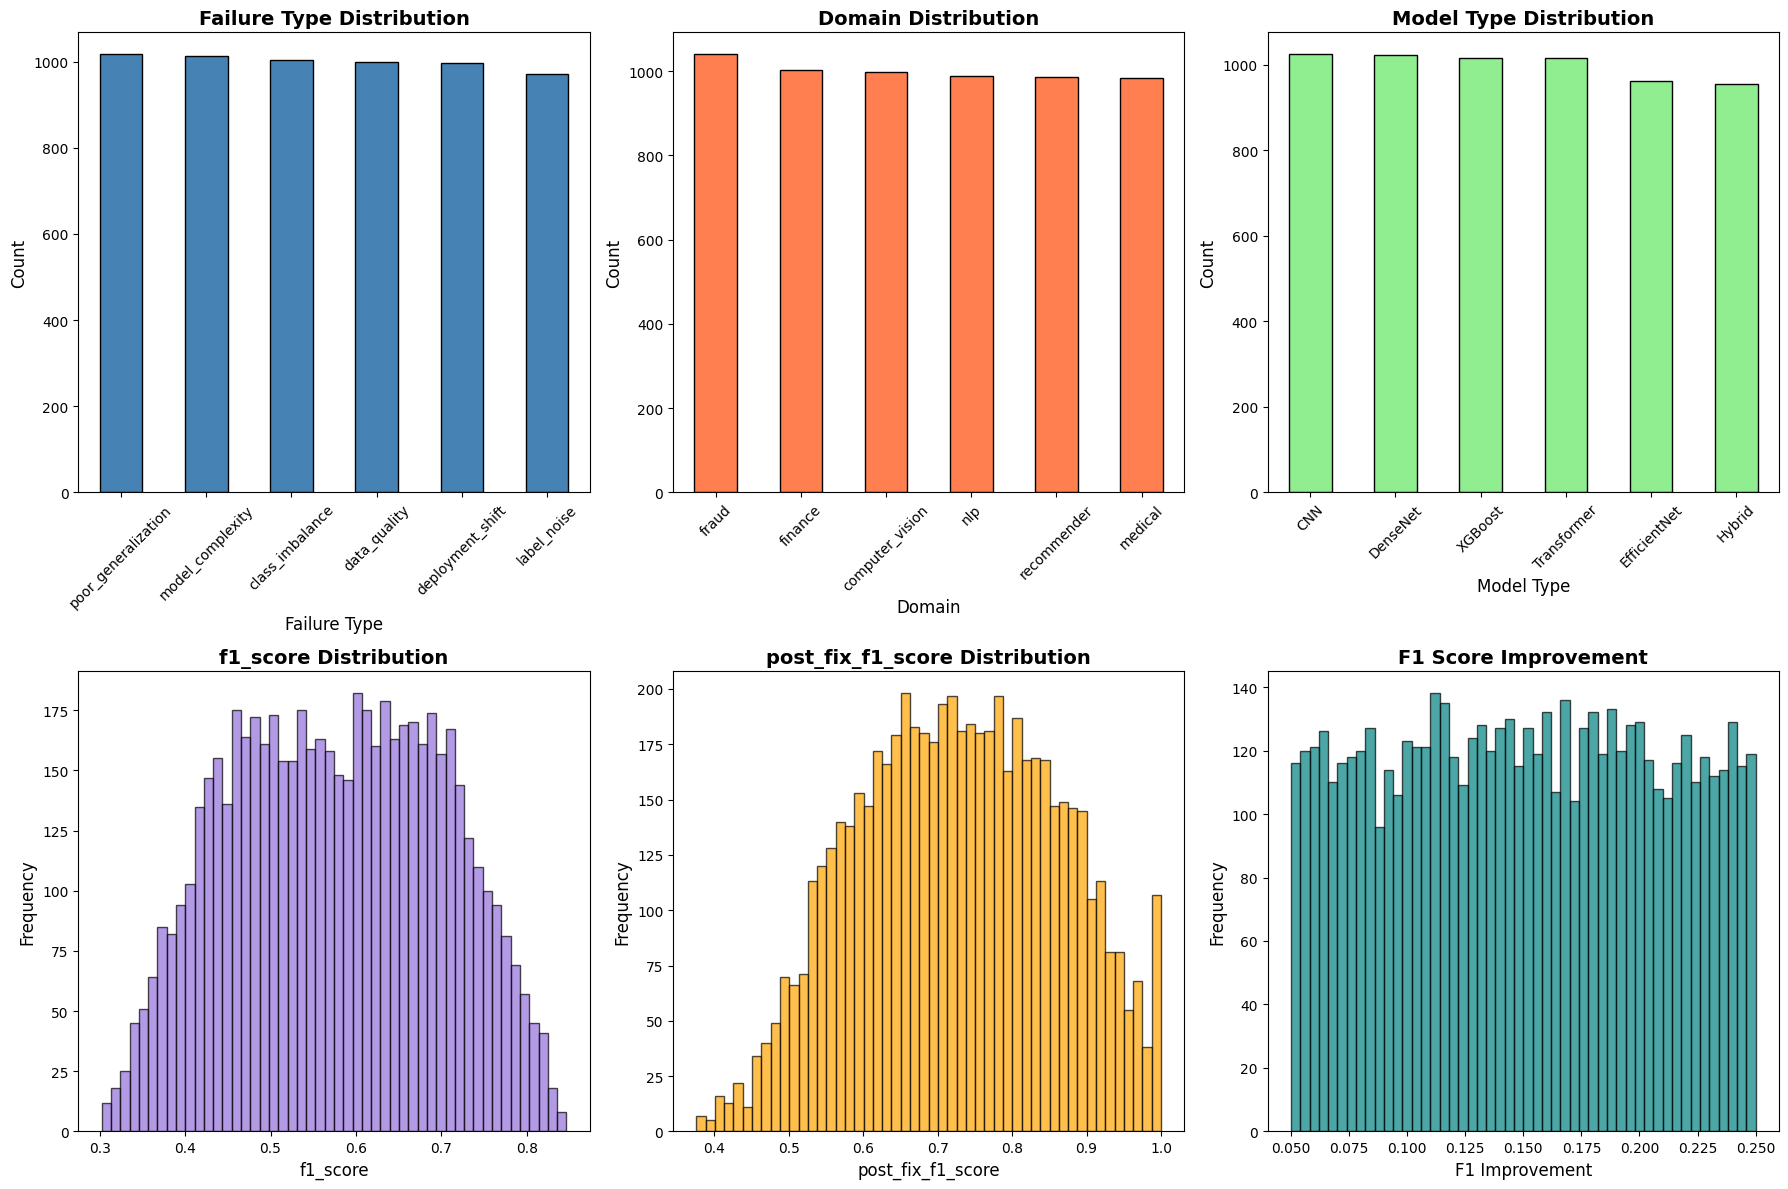


🔗 Correlation Analysis
--------------------------------------------------

Top 10 features correlated with post_fix_f1_score:
post_fix_f1_score     1.000000
f1_score              0.905420
accuracy              0.846877
f1_improvement        0.415639
missing_data_ratio    0.022349
recall                0.018763
data_leakage          0.013294
train_val_gap         0.010635
underfitting_flag     0.009875
year                  0.009720
roc_auc               0.008242
Name: post_fix_f1_score, dtype: float64


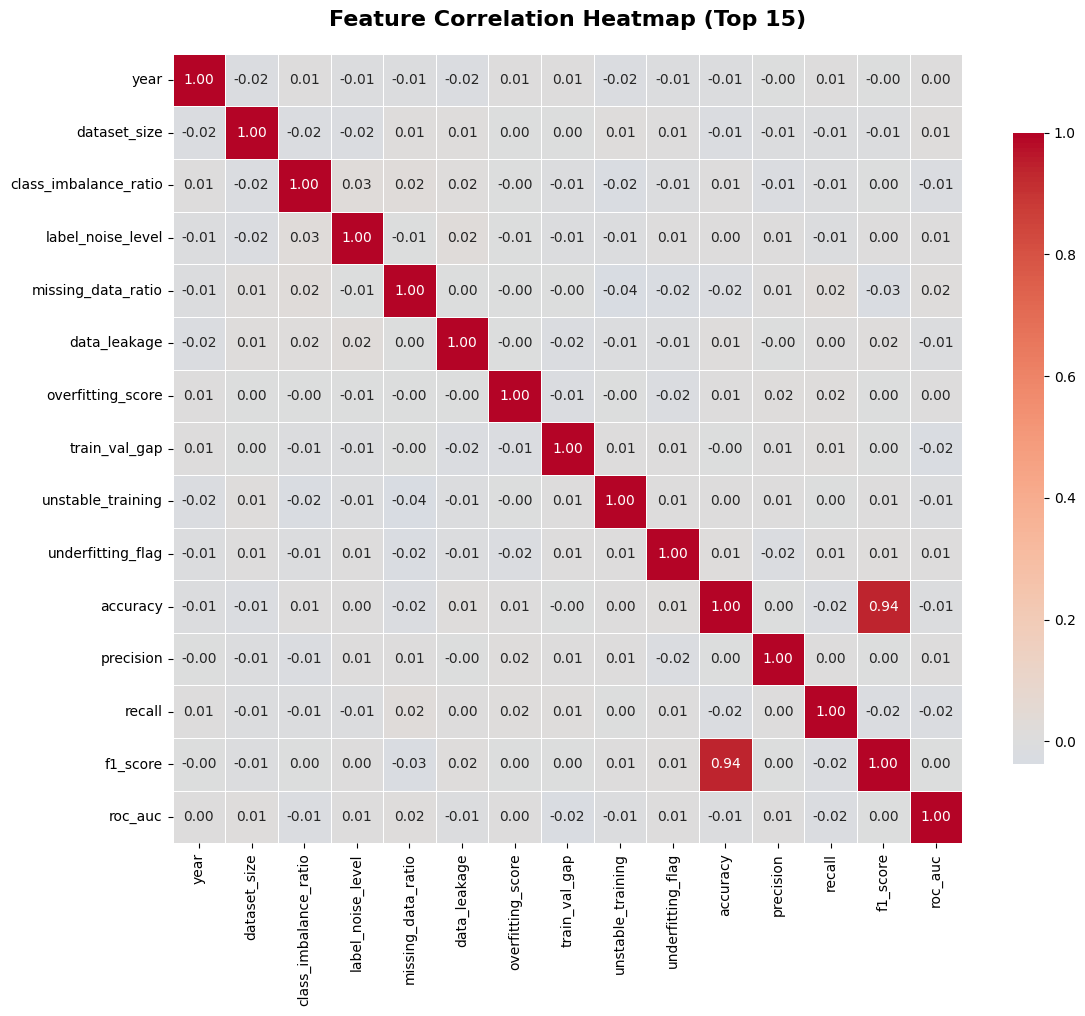

In [30]:
print("\n" + "="*80)
print("EXPLORATORY DATA ANALYSIS")
print("="*80 + "\n")

failure_cols = [col for col in df_clean.columns if 'failure' in col.lower()]
if len(failure_cols) > 0:
    failure_col = failure_cols[0]
    print(f"Failure Type Distribution ('{failure_col}'):")
    failure_dist = df_clean[failure_col].value_counts()
    print(failure_dist)
    print(f"\n   Percentages:")
    print(failure_dist / len(df_clean) * 100)

# Domain distribution
domain_cols = [col for col in df_clean.columns if 'domain' in col.lower()]
if len(domain_cols) > 0:
    domain_col = domain_cols[0]
    print(f"\n🌍 Domain Distribution ('{domain_col}'):")
    print(df_clean[domain_col].value_counts())

model_cols = [col for col in df_clean.columns if 'model_type' in col.lower()]
if len(model_cols) > 0:
    model_col = model_cols[0]
    print(f"\n🤖 Model Type Distribution ('{model_col}'):")
    print(df_clean[model_col].value_counts())

f1_cols = [col for col in df_clean.columns if 'f1' in col.lower()]
if len(f1_cols) > 0:
    for f1_col in f1_cols:
        print(f"\n {f1_col} Distribution:")
        print(f"   Mean: {df_clean[f1_col].mean():.4f}")
        print(f"   Median: {df_clean[f1_col].median():.4f}")
        print(f"   Std Dev: {df_clean[f1_col].std():.4f}")
        print(f"   Min: {df_clean[f1_col].min():.4f}")
        print(f"   Max: {df_clean[f1_col].max():.4f}")

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

if len(failure_cols) > 0:
    df_clean[failure_col].value_counts().plot(kind='bar', ax=axes[0, 0], color='steelblue', edgecolor='black')
    axes[0, 0].set_title('Failure Type Distribution', fontsize=14, fontweight='bold')
    axes[0, 0].set_xlabel('Failure Type', fontsize=12)
    axes[0, 0].set_ylabel('Count', fontsize=12)
    axes[0, 0].tick_params(axis='x', rotation=45)

if len(domain_cols) > 0:
    df_clean[domain_col].value_counts().plot(kind='bar', ax=axes[0, 1], color='coral', edgecolor='black')
    axes[0, 1].set_title('Domain Distribution', fontsize=14, fontweight='bold')
    axes[0, 1].set_xlabel('Domain', fontsize=12)
    axes[0, 1].set_ylabel('Count', fontsize=12)
    axes[0, 1].tick_params(axis='x', rotation=45)

if len(model_cols) > 0:
    df_clean[model_col].value_counts().plot(kind='bar', ax=axes[0, 2], color='lightgreen', edgecolor='black')
    axes[0, 2].set_title('Model Type Distribution', fontsize=14, fontweight='bold')
    axes[0, 2].set_xlabel('Model Type', fontsize=12)
    axes[0, 2].set_ylabel('Count', fontsize=12)
    axes[0, 2].tick_params(axis='x', rotation=45)

if len(f1_cols) >= 2:
    axes[1, 0].hist(df_clean[f1_cols[0]], bins=50, color='mediumpurple', edgecolor='black', alpha=0.7)
    axes[1, 0].set_title(f'{f1_cols[0]} Distribution', fontsize=14, fontweight='bold')
    axes[1, 0].set_xlabel(f'{f1_cols[0]}', fontsize=12)
    axes[1, 0].set_ylabel('Frequency', fontsize=12)

    axes[1, 1].hist(df_clean[f1_cols[1]], bins=50, color='orange', edgecolor='black', alpha=0.7)
    axes[1, 1].set_title(f'{f1_cols[1]} Distribution', fontsize=14, fontweight='bold')
    axes[1, 1].set_xlabel(f'{f1_cols[1]}', fontsize=12)
    axes[1, 1].set_ylabel('Frequency', fontsize=12)

    if 'post_fix_f1_score' in f1_cols and 'f1_score' in f1_cols:
        df_clean['f1_improvement'] = df_clean['post_fix_f1_score'] - df_clean['f1_score']
        axes[1, 2].hist(df_clean['f1_improvement'], bins=50, color='teal', edgecolor='black', alpha=0.7)
        axes[1, 2].set_title('F1 Score Improvement', fontsize=14, fontweight='bold')
        axes[1, 2].set_xlabel('F1 Improvement', fontsize=12)
        axes[1, 2].set_ylabel('Frequency', fontsize=12)

plt.tight_layout()
plt.savefig('eda_visualizations.png')
plt.show()

print("\n🔗 Correlation Analysis")
print("-" * 50)

numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
if len(numeric_cols) > 1:
    if 'post_fix_f1_score' in numeric_cols:
        target_corr = df_clean[numeric_cols].corr()['post_fix_f1_score'].abs().sort_values(ascending=False)
        print(f"\nTop 10 features correlated with post_fix_f1_score:")
        print(target_corr.head(11))  
    top_features = numeric_cols[:min(15, len(numeric_cols))]
    corr_matrix = df_clean[top_features].corr()

    plt.figure(figsize=(12, 10))
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
    plt.title('Feature Correlation Heatmap (Top 15)', fontsize=16, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.savefig('correlation_heatmap.png')
    plt.show()